**Loading libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

**Loading the dataset**

In [3]:
df = pd.read_csv('household_power_consumption.txt', 
                 sep=';', 
                 parse_dates={'Datetime': ['Date', 'Time']}, 
                 dayfirst=True, 
                 low_memory=False, 
                 na_values=['?'])

C:\Users\JMR\AppData\Local\Temp\ipykernel_18528\4244627103.py:1: FutureWarning: Support for nested sequences for 'parse_dates' in pd.read_csv is deprecated. Combine the desired columns with pd.to_datetime after parsing instead.
  df = pd.read_csv('household_power_consumption.txt',


**Setting Date Time as the index**

In [4]:
df.set_index('Datetime', inplace=True)

**Handling Missing Values**

In [5]:
df = df.ffill()

In [7]:
df['Global_active_power'] = pd.to_numeric(df['Global_active_power'])  #making sure the power column is numeric

In [8]:

df_daily = df['Global_active_power'].resample('D').sum()    # Converting 1-minute intervals to daily totals (sum)

**Visualization**

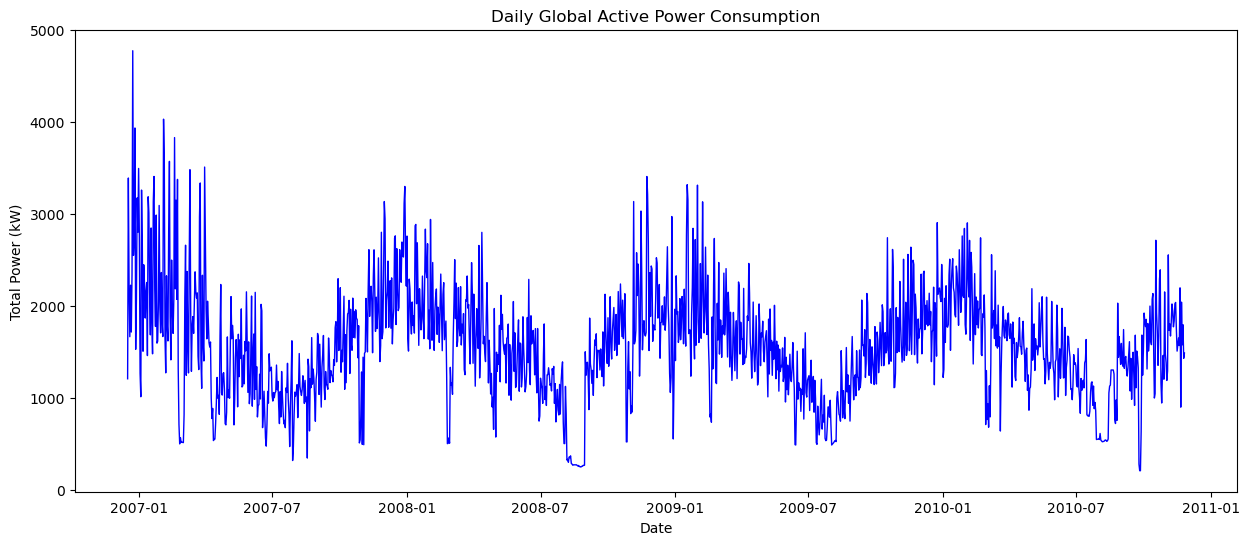

In [9]:
plt.figure(figsize=(15, 6))
plt.plot(df_daily, color='blue', linewidth=1)
plt.title('Daily Global Active Power Consumption')
plt.xlabel('Date')
plt.ylabel('Total Power (kW)')
plt.show()

In [10]:
print("Resampled Data Head:")
print(df_daily.head())

Resampled Data Head:
Datetime
2006-12-16    1209.176
2006-12-17    3390.460
2006-12-18    2203.826
2006-12-19    1666.194
2006-12-20    2225.748
Freq: D, Name: Global_active_power, dtype: float64


**Feature Engineering**

**Resample to Hourly**

C:\Users\JMR\AppData\Local\Temp\ipykernel_18528\4117817354.py:3: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  df_hourly = df['Global_active_power'].resample('H').mean().to_frame()


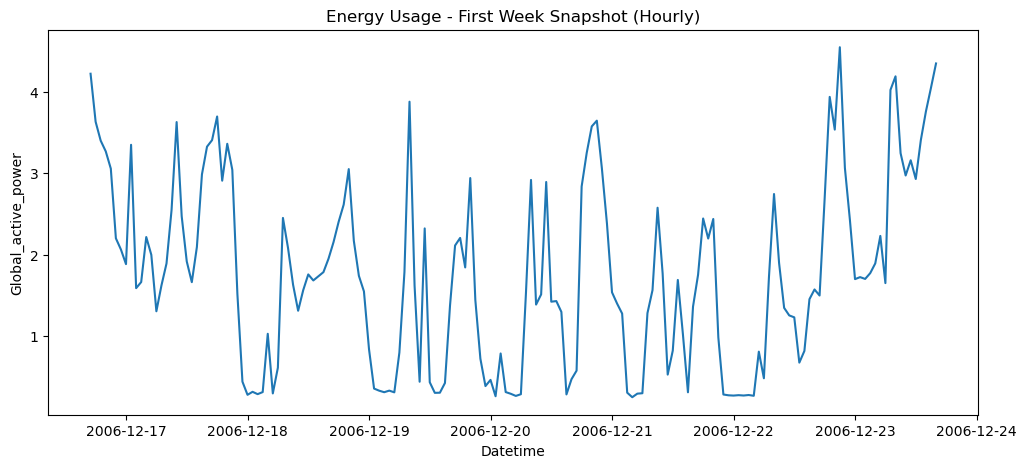

                     Global_active_power  hour  dayofweek  month  year  \
Datetime                                                                 
2006-12-16 17:00:00             4.222889    17          5     12  2006   
2006-12-16 18:00:00             3.632200    18          5     12  2006   
2006-12-16 19:00:00             3.400233    19          5     12  2006   
2006-12-16 20:00:00             3.268567    20          5     12  2006   
2006-12-16 21:00:00             3.056467    21          5     12  2006   

                     is_weekend  
Datetime                         
2006-12-16 17:00:00           1  
2006-12-16 18:00:00           1  
2006-12-16 19:00:00           1  
2006-12-16 20:00:00           1  
2006-12-16 21:00:00           1  


In [15]:
import seaborn as sns
import matplotlib.pyplot as plt
df_hourly = df['Global_active_power'].resample('H').mean().to_frame()
def create_features(df):
    df = df.copy()
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['year'] = df.index.year
    df['is_weekend'] = df['dayofweek'].apply(lambda x: 1 if x >= 5 else 0)
    return df

df_features = create_features(df_hourly)

plt.figure(figsize=(12, 5))
sns.lineplot(data=df_features.head(24*7), x=df_features.head(24*7).index, y='Global_active_power')
plt.title('Energy Usage - First Week Snapshot (Hourly)')
plt.show()

print(df_features.head())

In [16]:

df_features = create_features(df_hourly)   # Applying feature engineering


**Visualize the "Hour of Day" pattern**

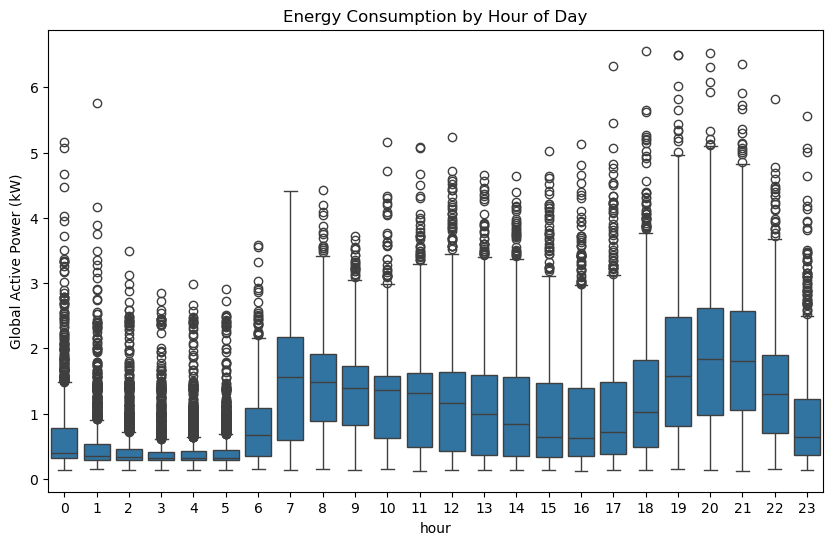

In [17]:
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_features, x='hour', y='Global_active_power')
plt.title('Energy Consumption by Hour of Day')
plt.ylabel('Global Active Power (kW)')
plt.show()

In [18]:
print(df_features.head())

                     Global_active_power  hour  dayofweek  month  year  \
Datetime                                                                 
2006-12-16 17:00:00             4.222889    17          5     12  2006   
2006-12-16 18:00:00             3.632200    18          5     12  2006   
2006-12-16 19:00:00             3.400233    19          5     12  2006   
2006-12-16 20:00:00             3.268567    20          5     12  2006   
2006-12-16 21:00:00             3.056467    21          5     12  2006   

                     is_weekend  
Datetime                         
2006-12-16 17:00:00           1  
2006-12-16 18:00:00           1  
2006-12-16 19:00:00           1  
2006-12-16 20:00:00           1  
2006-12-16 21:00:00           1  


**Model Comparison**

**Part A: XG Boost Preparation**

In [21]:
!pip install xgboost prophet statsmodels

Defaulting to user installation because normal site-packages is not writeable
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   ---------------------------------------- 0.3/101.7 MB ? eta -:--:--
   ---------------------------------------- 1.0/101.7 MB 3.3 MB/s eta 0:00:31
    --------------------------------------- 2.4/101.7 MB 4.2 MB/s eta 0:00:24
   - -------------------------------------- 3.9/101.7 MB 5.2 MB/s eta 0:00:19
   - -------------------------------------- 3.9/101.7 MB 5.2 MB/s eta 0:00:19
   -- ------------------------------------- 6.6/101.7 MB 5.8 MB/s eta 0:00:17
   -- ------------------------------------- 7.1/101.7 MB 5.4 MB/s eta 0:00:18
   -- ------------------------------------- 7.6/101.7 MB 4.7 MB/s eta 0:00:21
   --- ------------------------------------ 8.9/101.7 MB 5.0 MB/s eta 0:00:19
   --- ------------------------------------ 10.0/101.7 MB 4.8 MB/s eta 0:00:20
   ---

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.


**Part A: XG Boost and Prophet**

In [22]:
import xgboost as xgb
from prophet import Prophet
from sklearn.metrics import mean_squared_error, mean_absolute_error
# 1. Preparing  a smaller subset for faster training (Last 6 months of the data)
recent_data = df_features.loc[df_features.index > '2010-06-01']
train = recent_data.loc[recent_data.index < '2010-11-01']
test = recent_data.loc[recent_data.index >= '2010-11-01']
X_train, y_train = train[['hour', 'dayofweek', 'month', 'year', 'is_weekend']], train['Global_active_power']
X_test, y_test = test[['hour', 'dayofweek', 'month', 'year', 'is_weekend']], test['Global_active_power']
reg = xgb.XGBRegressor(n_estimators=500)
reg.fit(X_train, y_train)
test = test.copy()
test['XGB_Prediction'] = reg.predict(X_test)
prophet_df = train.reset_index().rename(columns={'Datetime':'ds', 'Global_active_power':'y'})
model_prophet = Prophet()
model_prophet.fit(prophet_df)
future = test.reset_index().rename(columns={'Datetime':'ds'})[['ds']]
forecast = model_prophet.predict(future)
test['Prophet_Prediction'] = forecast['yhat'].values
print("XGBoost and Prophet Training Complete!")

16:08:39 - cmdstanpy - INFO - Chain [1] start processing
16:08:40 - cmdstanpy - INFO - Chain [1] done processing


XGBoost and Prophet Training Complete!


**Part B: Arima**

In [23]:
from statsmodels.tsa.arima.model import ARIMA
history = train['Global_active_power']
model_arima = ARIMA(history, order=(5,1,0)) # Simple order for speed
model_arima_fit = model_arima.fit()
test['ARIMA_Prediction'] = model_arima_fit.forecast(steps=len(test)).values
print("ARIMA Training Complete!")

ARIMA Training Complete!


**Model Evaluation and Visualizing**

In [24]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

In [25]:

def get_metrics(actual, predicted):     #Function to calculate metrics
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    return mae, rmse

In [26]:
metrics = {}                             # Calculating for all models
metrics['XGBoost'] = get_metrics(test['Global_active_power'], test['XGB_Prediction'])
metrics['Prophet'] = get_metrics(test['Global_active_power'], test['Prophet_Prediction'])
metrics['ARIMA'] = get_metrics(test['Global_active_power'], test['ARIMA_Prediction'])

In [27]:
comparison_df = pd.DataFrame(metrics, index=['MAE', 'RMSE']).T   #Creating a compartison table
print("Model Performance Comparison:")
print(comparison_df)

Model Performance Comparison:
              MAE      RMSE
XGBoost  0.504243  0.700579
Prophet  0.586999  0.740667
ARIMA    0.732910  0.884483


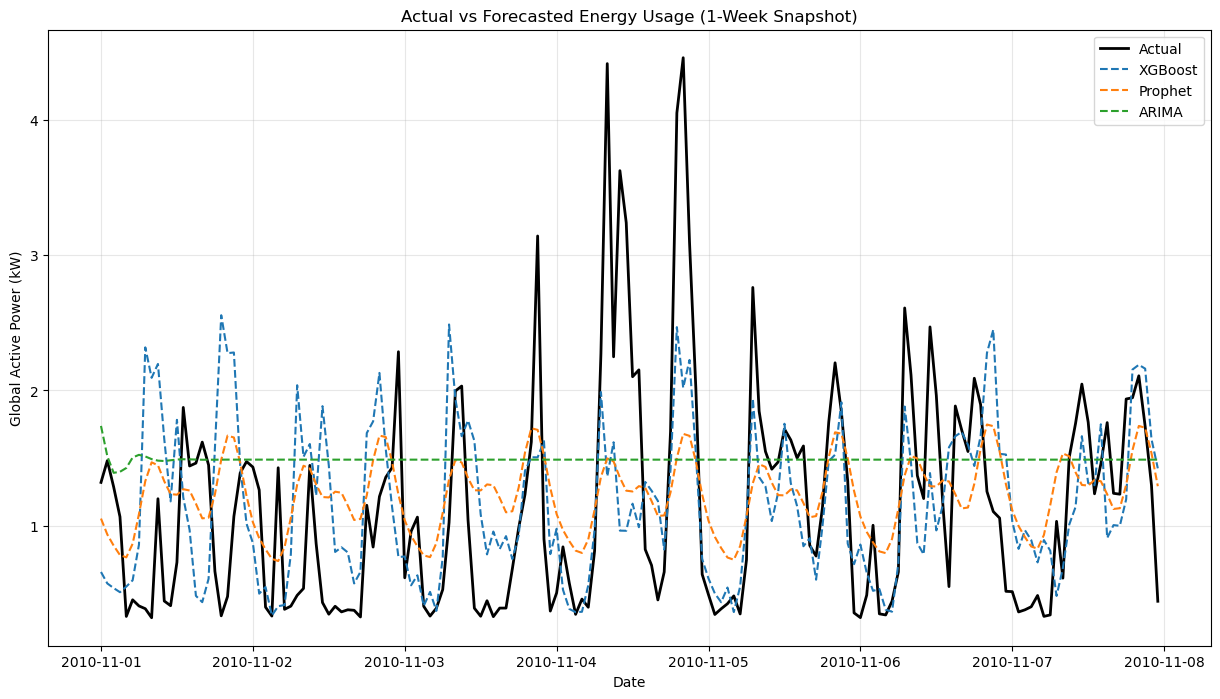

In [28]:
#Visualization
plt.figure(figsize=(15, 8))
plt.plot(test.index[:168], test['Global_active_power'][:168], label='Actual', color='black', linewidth=2)
plt.plot(test.index[:168], test['XGB_Prediction'][:168], label='XGBoost', linestyle='--')
plt.plot(test.index[:168], test['Prophet_Prediction'][:168], label='Prophet', linestyle='--')
plt.plot(test.index[:168], test['ARIMA_Prediction'][:168], label='ARIMA', linestyle='--')
plt.title('Actual vs Forecasted Energy Usage (1-Week Snapshot)')
plt.xlabel('Date')
plt.ylabel('Global Active Power (kW)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()